In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

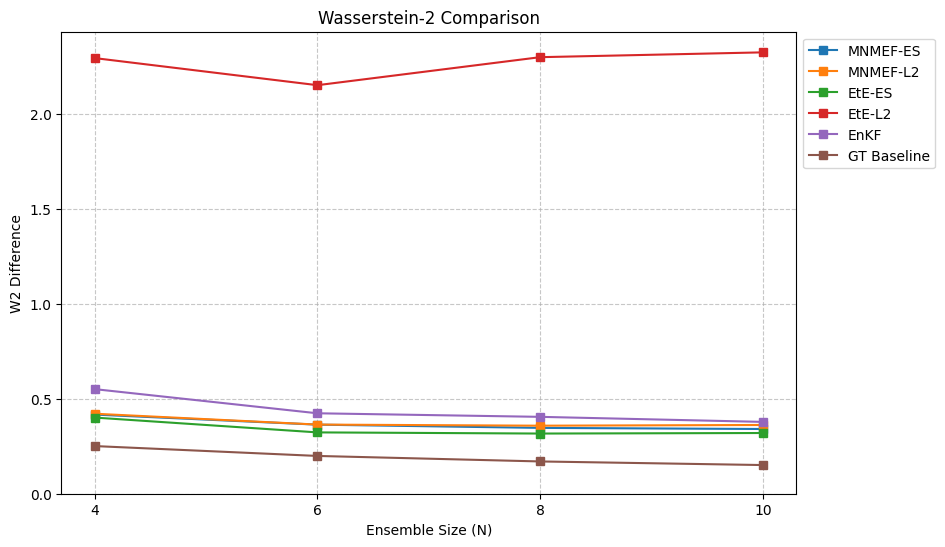

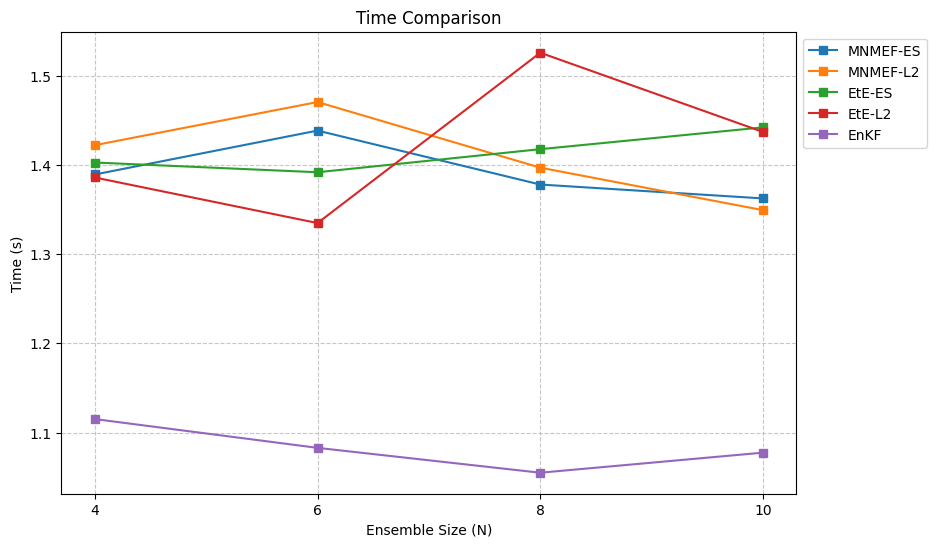

In [6]:
import os
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

base_W2 = [0.251, 0.199, 0.170, 0.151]

# --- [DATA LOADING AND PREPARATION - UNCHANGED EXCEPT NEW METRICS] ---
PF_Cov_Diff_95CI = 0
PF_RCov_Diff_95CI = 0
ensemble_sizes = [4,6,8,10]

data_folders = [
    "linear_es_vs_l2/2025-08-14_20-05linear_1_10_60_8192_es_joint_CorrTerms",
    "linear_es_vs_l2/2025-08-14_20-04linear_1_10_60_8192_l2_joint_CorrTerms",
    "linear_es_vs_l2/2025-08-14_19-59linear_1_10_60_8192_es_joint_EtE-LRes_nst",
    "linear_es_vs_l2/2025-08-14_20-04linear_1_10_60_8192_l2_joint_EtE-LRes_nst",
    "linear_es_vs_l2/benchmark_linear_1.0_EnKF",
]

method_names = [
    'MNMEF-ES',
    'MNMEF-L2',
    'EtE-ES',        # always nst
    'EtE-L2',
    "EnKF",
]

results = {}

num_sizes = len(ensemble_sizes)
for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)

        # Load file
        data = torch.load(data_file, weights_only=True)

        # Required metrics
        cov_diff = data["nn"]['cov_diff']
        w2_diff = data["nn"]['w2_diff']
        t = data["time"]

        # Initialize buckets
        results.setdefault(method_name, {})
        for key in ['cov_diff', 'w2_diff', 'rrmse', 'rcov_diff', 'time']:
            results[method_name].setdefault(key, [])

        # Append metrics
        results[method_name]['cov_diff'].append(cov_diff)
        results[method_name]['w2_diff'].append(w2_diff)
        results[method_name]['time'].append(t)

fig4, ax2 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax2.plot(ensemble_sizes, results[key]['w2_diff'], marker='s', label=key)
ax2.plot(ensemble_sizes, base_W2, marker='s', label="GT Baseline")
ax2.set_title('Wasserstein-2 Comparison')
ax2.set_xlabel('Ensemble Size (N)')
ax2.set_ylabel('W2 Difference')
ax2.set_xticks(ensemble_sizes)
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig4.subplots_adjust(right=0.65)

# --- Figure 5: Time ---
fig5, ax5 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax5.plot(ensemble_sizes, results[key]['time'], marker='s', label=key)
ax5.set_title('Time Comparison')
ax5.set_xlabel('Ensemble Size (N)')
ax5.set_ylabel('Time (s)')
ax5.set_xticks(ensemble_sizes)
ax5.grid(True, linestyle='--', alpha=0.7)
ax5.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig5.subplots_adjust(right=0.65)

# Show all plots
plt.show()
